2.1 理论计算题
# 1. 输出特征图尺寸
卷积输出尺寸公式：
$$O=\left\lfloor \frac{H_{in}+2P-K}{S} \right\rfloor +1$$
已知：$H_{in}=W_{in}=32,\ P=2,\ K=5,\ S=2$
$$O=\frac{32+2\times2-5}{2}+1=16$$
输出通道数 = 卷积核数量 = 16
输出尺寸：$\boldsymbol{16 \times 16 \times 16}$

# 2. 单点乘法次数
单个卷积核尺寸 $3\times5\times5$，点乘乘法次数等于参数总量：
$$3 \times 5 \times 5 = \boldsymbol{75}$$



In [1]:
#2.2 编程题
import numpy as np

def max_pool2d(x, kernel_size, stride, padding):
    # x shape: [N, C, H_in, W_in]
    N, C, H_in, W_in = x.shape
    kh, kw = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
    ph, pw = padding if isinstance(padding, tuple) else (padding, padding)
    sh, sw = stride if isinstance(stride, tuple) else (stride, stride)
    
    # 1. 填充
    x_pad = np.pad(x, ((0,0), (0,0), (ph,ph), (pw,pw)), mode='constant', constant_values=0)
    H_pad, W_pad = x_pad.shape[2], x_pad.shape[3]
    
    # 2. 输出尺寸
    H_out = (H_pad - kh) // sh + 1
    W_out = (W_pad - kw) // sw + 1
    out = np.zeros((N, C, H_out, W_out))
    
    # 3. 滑动窗口取最大值
    for n in range(N):
        for c in range(C):
            for i in range(H_out):
                h_start = i * sh
                h_end = h_start + kh
                for j in range(W_out):
                    w_start = j * sw
                    w_end = w_start + kw
                    window = x_pad[n, c, h_start:h_end, w_start:w_end]
                    out[n, c, i, j] = np.max(window)
    return out

# 测试
if __name__ == "__main__":
    img = np.array([[[[1,2,3],[4,5,6],[7,8,9]]]])  # N=1,C=1,H=3,W=3
    res = max_pool2d(img, kernel_size=2, stride=1, padding=1)
    print(res)

[[[[1. 2. 3. 3.]
   [4. 5. 6. 6.]
   [7. 8. 9. 9.]
   [7. 8. 9. 9.]]]]


3.1 理论计算题

### 1. 单个 $5\times5$ 卷积层参数量
输入通道=$C$，输出通道=$C$，卷积核尺寸$5\times5$，无偏置
$$
\begin{align}
Params_{5\times5} &= C \times C \times 5 \times 5 \\
&= \boldsymbol{25C^2}
\end{align}
$$

### 2. 两层串联 $3\times3$ 卷积总参数量
两层均为输入通道$C$、输出通道$C$，卷积核$3\times3$，无偏置
单层$3\times3$参数量：$C \times C \times 3 \times 3 = 9C^2$
两层总和：
$$
\begin{align}
Params_{2\times3\times3} &= 9C^2 + 9C^2 \\
&= \boldsymbol{18C^2}
\end{align}
$$

## 补充结论对比
$18C^2 < 25C^2$，说明两层$3\times3$级联感受野等价于一层$5\times5$，但参数量更少，是VGG设计的核心优势。

In [2]:
#3.2 编程题
import torch
import torch.nn as nn

class NiNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, padding):
        super().__init__()
        # 按要求搭建：普通卷积 + ReLU → 1×1卷积 + ReLU → 1×1卷积 + ReLU
        self.block = nn.Sequential(
            # 第一层常规卷积
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.ReLU(),
            # 第一个1×1卷积
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU(),
            # 第二个1×1卷积
            nn.Conv2d(out_channels, out_channels, kernel_size=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)

# 测试示例
if __name__ == "__main__":
    # 构造一个NiN块：输入通道3，输出通道16，卷积核3，步幅1，填充1
    nin_block = NiNBlock(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
    # 随机输入：batch=2, channel=3, H=32, W=32
    test_input = torch.randn(2, 3, 32, 32)
    output = nin_block(test_input)
    print("输出特征图尺寸：", output.shape)

输出特征图尺寸： torch.Size([2, 16, 32, 32])


4.1理论计算题
## 一、BN 前向公式
$$
y = \gamma \cdot \frac{x-\mu}{\sqrt{\sigma^2+\epsilon}} + \beta
$$
已知：$x_1=2,x_2=4,x_3=6,x_4=8,\ \gamma=2,\ \beta=1,\ \epsilon=0$

### 1：计算批次均值 $\mu$
$$
\mu = \frac{2+4+6+8}{4} = \frac{20}{4} = 5
$$

### 2：计算方差 $\sigma^2$
$$
\begin{align}
\sigma^2 &= \frac{(2-5)^2 + (4-5)^2 + (6-5)^2 + (8-5)^2}{4} \\
&= \frac{9 + 1 + 1 + 9}{4} \\
&= \frac{20}{4} = 5
\end{align}
$$

### 3：代入公式计算每个输出
$\sqrt{\sigma^2+\epsilon}=\sqrt{5}$，标准化项：$\displaystyle z=\frac{x-5}{\sqrt{5}}$，最终 $y=2z+1$

1. $x_1=2$
$$
y_1 = 2\cdot\frac{2-5}{\sqrt{5}} + 1 = 1 - \frac{6}{\sqrt{5}} \approx -1.683
$$
2. $x_2=4$
$$
y_2 = 2\cdot\frac{4-5}{\sqrt{5}} + 1 = 1 - \frac{2}{\sqrt{5}} \approx 0.106
$$
3. $x_3=6$
$$
y_3 = 2\cdot\frac{6-5}{\sqrt{5}} + 1 = 1 + \frac{2}{\sqrt{5}} \approx 1.894
$$
4. $x_4=8$
$$
y_4 = 2\cdot\frac{8-5}{\sqrt{5}} + 1 = 1 + \frac{6}{\sqrt{5}} \approx 4.683
$$

---
## 结果
$$
\begin{aligned}
y_1 &= 1 - \dfrac{6\sqrt{5}}{5},\\
y_2 &= 1 - \dfrac{2\sqrt{5}}{5},\\
y_3 &= 1 + \dfrac{2\sqrt{5}}{5},\\
y_4 &= 1 + \dfrac{6\sqrt{5}}{5}.
\end{aligned}
$$

In [3]:
# 4.2 编程题
import torch
import torch.nn as nn

class Residual(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, use_1x1conv=False):
        super().__init__()
        # 主分支：两层3×3卷积 + BN
        self.main_branch = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        # 1×1下采样分支，匹配通道与尺寸
        if use_1x1conv:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        fx = self.main_branch(x)
        x_short = self.shortcut(x)
        out = fx + x_short  # 残差相加
        return torch.relu(out)

# 测试代码
if __name__ == "__main__":
    # 1. 通道不变、步幅1，无需1×1卷积
    block1 = Residual(in_channels=64, out_channels=64, stride=1, use_1x1conv=False)
    test_x1 = torch.randn(2, 64, 32, 32)
    print("block1输出尺寸:", block1(test_x1).shape)

    # 2. 通道翻倍、下采样，启用1×1卷积对齐shortcut
    block2 = Residual(in_channels=64, out_channels=128, stride=2, use_1x1conv=True)
    test_x2 = torch.randn(2, 64, 32, 32)
    print("block2输出尺寸:", block2(test_x2).shape)

block1输出尺寸: torch.Size([2, 64, 32, 32])
block2输出尺寸: torch.Size([2, 128, 16, 16])


5.1 理论计算题
## 1. 分层差异化学习率的原因
### 底层特征提取层（预训练参数）
1. **特征通用性强**：底层卷积提取边缘、纹理、色块等通用视觉特征，源数据集（ImageNet）学到的特征对新任务依然有效，不需要大幅修改；
2. **防止破坏预训练先验**：若学习率过大，少量目标数据集样本会大幅改动成熟的底层权重，丢失通用视觉知识，极易过拟合；
3. **参数稳定需求**：因此设置极小学习率或直接冻结参数，仅做细微修正，保留已学到的通用特征。

### 顶层输出层（全新初始化）
1. **无先验知识**：顶层全连接/分类层是随机初始化，完全不匹配目标数据集分类任务，需要快速收敛适配新类别；
2. **任务适配需求**：仅顶层负责区分目标数据集类别，需要更大梯度更新幅度快速拟合新数据分布；
3. **梯度安全**：顶层权重数量远少于底层卷积层，大学习率不会破坏底层通用特征，风险更低。

---
## 2. 数据集很小、与源数据集高度相似时的防过拟合微调策略
1. **完全冻结全部卷积底层，仅训练顶层分类头**
    底层全部参数固定，只更新最后输出层权重。由于源域与目标域相似，预训练特征完全可用，极小数据不会污染通用特征，从根源减少可训练参数量。
2. **搭配强正则化手段**
    - 分类层加入Dropout、权重衰减（L2正则）；
    - 使用图像增广（随机裁剪、翻转、色彩抖动）扩充有限样本；
    - 采用早停（Early Stopping），监控验证集损失，防止在小数据集上过拟合。
3. **使用极小学习率（如需微调少量底层）**
    若必须微调少量高层卷积，设置远小于顶层的学习率，避免权重剧烈偏移；不采用全局统一大学习率。
4. **采用轻量更新策略**
    优先使用预训练特征做**特征提取（Feature Extraction）** 而非完整微调：固定卷积网络提取特征，仅训练浅层分类器，大幅降低模型拟合能力，适配小样本场景。

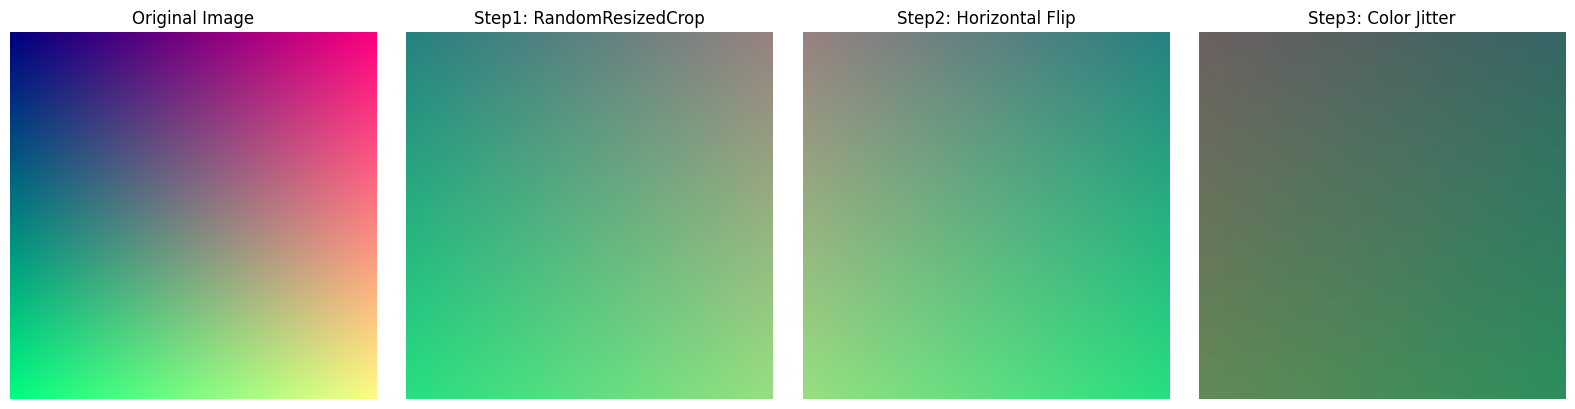

最终增强后Tensor形状： torch.Size([3, 224, 224])


In [ ]:
# 5.2 编程题
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# 1. 生成一张测试彩色图像（256×256 RGB）
def generate_test_img(w=256, h=256):
    arr = np.zeros((h, w, 3), dtype=np.uint8)
    # 绘制渐变色块方便观察增广效果
    for y in range(h):
        for x in range(w):
            arr[y, x, 0] = int(255 * x / w)    # R通道横向渐变
            arr[y, x, 1] = int(255 * y / h)    # G通道纵向渐变
            arr[y, x, 2] = 128
    return Image.fromarray(arr)

# 步骤
# 1. 随机面积裁剪+缩放至224×224，面积区间0.08~1.0
step1 = transforms.RandomResizedCrop(size=224, scale=(0.08, 1.0))

# 2. 50%概率水平翻转
step2 = transforms.RandomHorizontalFlip(p=1.0)  # 设p=1强制翻转用于展示效果

# 3. 随机亮度、对比度、饱和度变化，变化范围0.5
step3 = transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5)

# 4. 转为Tensor
to_tensor = transforms.ToTensor()

# 完整训练流水线
full_aug = transforms.Compose([step1, transforms.RandomHorizontalFlip(0.5), step3, to_tensor])

# 生成原图
origin_img = generate_test_img()
img_step1 = step1(origin_img)
img_step2 = step2(img_step1)
img_step3 = step3(img_step2)
tensor_final = full_aug(origin_img)

# 绘图展示每一步变化
plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(origin_img)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Step1: RandomResizedCrop")
plt.imshow(img_step1)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Step2: Horizontal Flip")
plt.imshow(img_step2)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Step3: Color Jitter")
plt.imshow(img_step3)
plt.axis("off")

plt.tight_layout()
plt.show()

print("最终增强后Tensor形状：", tensor_final.shape)

6.1 理论计算题

### 1：计算交集区域坐标
交集左上角：$x_{in1}=\max(x_{a1},x_{b1}),\ y_{in1}=\max(y_{a1},y_{b1})$
交集右下角：$x_{in2}=\min(x_{a2},x_{b2}),\ y_{in2}=\min(y_{a2},y_{b2})$
$$
\begin{align}
x_{in1}&=\max(10,30)=30 \\
y_{in1}&=\max(10,30)=30 \\
x_{in2}&=\min(50,70)=50 \\
y_{in2}&=\min(50,70)=50
\end{align}
$$
交集宽高：
$$
w_{in}=50-30=20,\quad h_{in}=50-30=20
$$
交集面积：
$$
Area_{inter}=20\times20=400
$$

### 2：分别计算A、B框面积
框A宽高：$w_A=50-10=40,\ h_A=50-10=40$
$$
Area_A=40\times40=1600
$$
框B宽高：$w_B=70-30=40,\ h_B=70-30=40$
$$
Area_B=40\times40=1600
$$

### 3：计算并集面积
$$
Area_{union}=Area_A + Area_B - Area_{inter}=1600+1600-400=2800
$$

### 4：计算IoU
$$
IoU=\frac{400}{2800}=\frac{1}{7}\approx0.1429
$$

---
## 最终值
$$
\boldsymbol{IoU=\dfrac{1}{7}}
$$

In [9]:
#6.2 编程题
import torch
import torch.nn.functional as F

def label_smoothing_cross_entropy(logits, labels, num_classes, eps=0.1):
    """
    计算标签平滑后的交叉熵损失
    :param logits: 模型原始输出，shape [N, K]，未经过softmax
    :param labels: 真实标签，一维张量 [N]，值为类别索引
    :param num_classes: 分类总数 K
    :param eps: 平滑因子 ε，默认0.1
    :return: 批次平均损失标量
    """
    N = logits.shape[0]
    # Step1: 生成平滑后的目标分布
    smooth_target = torch.full((N, num_classes), fill_value=eps / (num_classes - 1), device=logits.device)
    # 正确类别位置赋值 1-ε
    smooth_target.scatter_(dim=1, index=labels.unsqueeze(1), value=1 - eps)
    
    # Step2: 计算log softmax
    log_probs = F.log_softmax(logits, dim=1)
    
    # Step3: 交叉熵 = -∑(target * log_prob)，逐样本求和再求批次均值
    loss = -torch.sum(smooth_target * log_probs, dim=1)
    return torch.mean(loss)


# 测试示例
if __name__ == "__main__":
    # 5分类，batch=2
    logits = torch.tensor([[2.0, 1.0, 0.5, -1.0, -2.0],
                           [0.3, 4.1, 1.2, -0.5, -3.0]])
    labels = torch.tensor([0, 1])
    loss = label_smoothing_cross_entropy(logits, labels, num_classes=5, eps=0.1)
    print("标签平滑交叉熵损失值：", loss.item())

标签平滑交叉熵损失值： 0.6441864967346191
